<a href="https://colab.research.google.com/github/moloruns/Olorunsola_DSPN_S26/blob/master/Exercise9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 9: Classification

This homework assignment is designed to give you practice with classification models. We'll try to predict which words are more likely to be responded to correctly during a lexical decision task, based on their length and frequency.

We will be using data from the English Lexicon Project again. However, this time we will use response correctness as our dependent variable. Load **LexicalData_withIncorrect.csv**, which includes incorrect trials as well as correct ones, and also **Items.csv**. Both can be found in the *Homework/lexDat* folder in the class GitHub repository.

This data is a subset of the [English Lexicon Project database](https://elexicon.wustl.edu/). It provides response correctness and reaction times (in milliseconds) of many subjects as they are presented with letter strings and asked to decide, as quickly and as accurately as possible, whether the letter string is a word or not. The **Items.csv** provides characteristics of the words used, namely frequency (how common is this word?) and length (how many letters?).

*Data courtesy of Balota, D.A., Yap, M.J., Cortese, M.J., Hutchison, K.A., Kessler, B., Loftis, B., Neely, J.H., Nelson, D.L., Simpson, G.B., & Treiman, R. (2007). The English Lexicon Project. Behavior Research Methods, 39, 445-459.*

---
## 1. Loading and formatting the data (2 point)

Load in data from the **LexicalData_withIncorrect.csv** and **Items.csv** files. Use `left_join` to add word characteristics `Length` and `Log_Freq_Hal` from **Items** to the **LexicalData**, and use `drop_na()` to get rid of any observations with missing values. Then use `head()` to look at the first few rows of the data.

*Note: We're just working with `Correct` in this homework, so no need to worry about reformatting reaction times.*

In [22]:
library(tidyverse)
lexDat <- read.csv("https://raw.githubusercontent.com/moloruns/Olorunsola_DSPN_S26/refs/heads/master/Exercise%20datasets/lexDat/LexicalData_withIncorrect.csv")
itemsDat <- read.csv("https://raw.githubusercontent.com/moloruns/Olorunsola_DSPN_S26/refs/heads/master/Exercise%20datasets/lexDat/Items.csv")

lexDat <- lexDat |>
  left_join(itemsDat, by = c("D_Word" = "Word")) |>
  drop_na()

head(lexDat)




,X,Sub_ID,Trial,Type,D_RT,D_Word,Outlier,D_Zscore,Correct,Occurrences,Length,Freq_HAL,Log_Freq_HAL
,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<int>,<chr>,<dbl>
1,1,157,1,1,710,browse,false,-0.437,1,2,6,"7,016",8.856
2,2,67,1,1,"1,094",refrigerant,false,0.825,1,3,11,104,4.644
3,3,120,1,1,587,gaining,false,-0.645,1,4,7,"4,039",8.304
4,4,21,1,1,984,cheerless,false,0.025,1,4,9,14,2.639
5,5,236,1,1,577,pattered,false,-0.763,1,4,8,4,1.386
6,6,236,2,1,715,conjures,false,-0.364,1,4,8,194,5.268


---
## 2. Visualizing the data (1 point)

First, we'll try to visualize whether trials that are responded to correctly versus incorrectly differ from each other in terms of word length and log frequency. The code is included below, so that this homework doesn't get too cumbersome. All you have to do is **change the name of the data set**, **run the code**, and **write some observations about the output**.

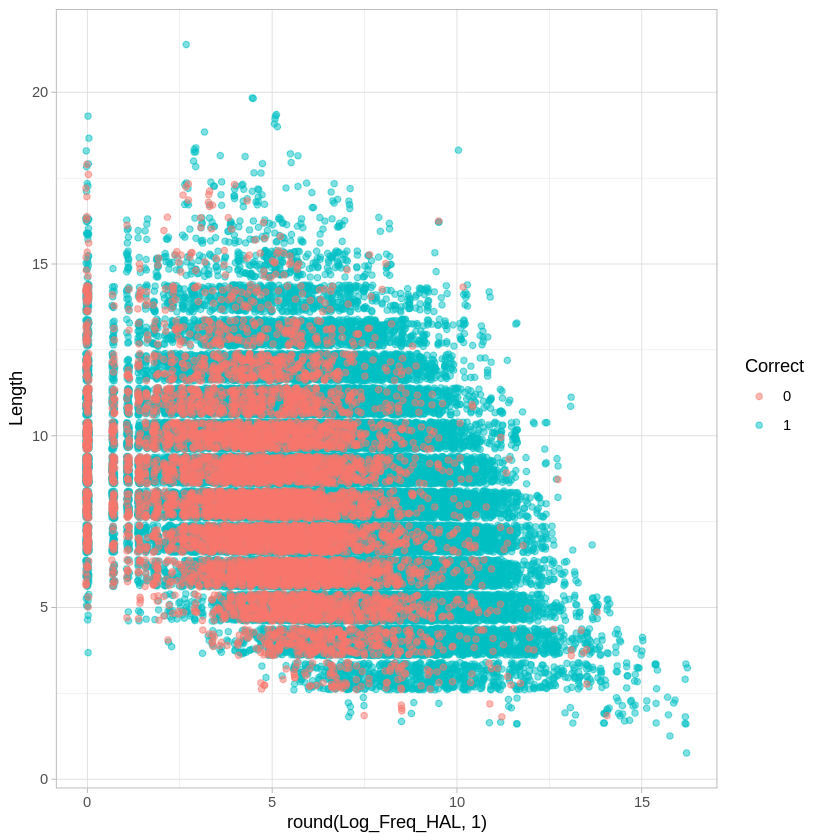

In [23]:
# Load the tidyverse package, if you haven't yet
lexDat$Correct <- as.factor(lexDat$Correct) # so that R knows that Correct is categorical, not numeric.

# plot the Correct / Incorrect clusters
ggplot(lexDat,aes(x=round(Log_Freq_HAL,1),y=Length,col=Correct)) + geom_point(position="jitter",alpha=0.5) + theme_light()


What do you observe about the "Correct" and "Incorrect" clusters?

> Both clusters appear to hover around the same length on average, while correct clusters seemingly vary more than incorrect clusters with `Log_Freq_HAL`.



---
## 3. Logistic Regression: Fitting the model (3 points)

Fit a logistic regression model to the data using `Length`, `Log_Freq_HAL`, and their interaction to predict `Correct`. Use `glm()` to fit the model, and look at its output using `summary()`.

In [24]:
mod <- glm(Correct ~ Length + Log_Freq_HAL + Length*Log_Freq_HAL, data = lexDat, family = "binomial")
summary(mod)




Call:
glm(formula = Correct ~ Length + Log_Freq_HAL + Length * Log_Freq_HAL, 
    family = "binomial", data = lexDat)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -0.939996   0.115623  -8.130 4.30e-16 ***
Length               0.151266   0.012789  11.828  < 2e-16 ***
Log_Freq_HAL         0.394772   0.018762  21.041  < 2e-16 ***
Length:Log_Freq_HAL -0.010558   0.002202  -4.795 1.63e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 49809  on 70588  degrees of freedom
Residual deviance: 46563  on 70585  degrees of freedom
AIC: 46571

Number of Fisher Scoring iterations: 5


What can you conclude from this output? (a brief gist is fine)

> Based on this output, I can conclude that all predictors are statistically significant. The model shows good fit with reasonable standard errors and a substantial reduction in deviance from the null model (49809 to 46563), indicating that the predictors here reliably predict lexical correctness.
>

---
## 4. Interpreting predictions from the model (4 points)

Finally, look at how well this logistic regression model does at predicting correctness. Use `predict()` and a threshold of 0.5 to generate predicted `Correct` values for each trial, then output a confusion matrix and overall accuracy for these predictions.

*Hint: see the Classifiers tutorial.*

In [29]:
t <- 0.5
glm_pred <- data.frame(predict(mod, type = "response"))
colnames(glm_pred) = c('pred_prob')
glm_pred$predicted <- rep("Incorrect", nrow(glm_pred))
glm_pred$predicted[glm_pred$pred_prob > t] <- "Correct"

confusion_mat <- data.frame(glm_pred$predicted, lexDat$Correct)
colnames(confusion_mat) <- c("predicted", "actual")
table(confusion_mat)



           actual
predicted       0     1
  Correct    7966 62566
  Incorrect    13    44

Did the model do well at predicting lexical decision correctness? Why or why not?

> No, the model did not perform well at predicting lexical decision correctness because it overwhelmingly predicts "Correct" for nearly all trials, failing to identify when errors actually occur.
>

**DUE:** 11:59pm EST, March 3, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *no*

**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.
>